# Brain Tumor Classification — DenseNet121 with Dual-Stage CBAM Attention



## Step 1: Imports

In [1]:
# Core
import os
import random
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
%pip install opencv-python
import seaborn as sns
import cv2

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import (
    Layer, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Reshape,
    Multiply, Add, Activation, Concatenate, Conv2D, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\amank\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


TensorFlow: 2.21.0
GPUs available: []


## Step 2: Configuration

Everything path- and hyperparameter-related lives here. Update the three paths at the top to match your machine; nothing else in the notebook hardcodes a path.

In [2]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

# ---- Paths: update these to match your local setup ----
TRAIN_DIR  = r"D:\Brain_tumor_project\Data set for brain tumor_main\Training"
TEST_DIR   = r"D:\Brain_tumor_project\Data set for brain tumor_main\Testing"
OUTPUT_DIR = r"D:\Brain_tumor_project\Notebook\output"
MODEL_DIR  = r"D:\Brain_tumor_project\Notebook\models"

# ---- Training schedule ----
VAL_SPLIT      = 0.15          # carved out of TRAIN_DIR; TEST_DIR stays fully held out
PHASE1_EPOCHS  = 25            # head only, backbone frozen
PHASE2_EPOCHS  = 30            # fine-tuning, top of backbone unfrozen
PHASE1_LR      = 1e-3
PHASE2_LR      = 1e-5
UNFREEZE_FROM_BLOCK = "conv5_block1"   # everything from this DenseNet121 block onward becomes trainable in phase 2
LABEL_SMOOTHING = 0.1
DROPOUT_RATE    = 0.5
CBAM_RATIO      = 8
CBAM_KERNEL     = 7

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

## Step 3: Data integrity check


In [3]:
def find_unreadable_images(root_dir):
    bad_files = []
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            img = cv2.imread(fpath)
            if img is None:
                bad_files.append(fpath)
    return bad_files

for name, d in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    bad = find_unreadable_images(d)
    print(f"{name}: {len(bad)} unreadable file(s)")
    if bad:
        print("  e.g.", bad[:5], "...")
        print("  Remove or fix these before continuing — image_dataset_from_directory will error on them.")

Training: 0 unreadable file(s)
Testing: 0 unreadable file(s)


## Step 4: Load data with `tf.data`

`TRAIN_DIR` is split into train/val; `TEST_DIR` is never touched until final evaluation.

In [4]:
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

raw_test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,                 # keep order stable so predictions line up with y_true later
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

CLASS_NAMES = raw_train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)

# Correctly-normalized versions for the model (DenseNet-specific preprocessing, not raw /255)
AUTOTUNE = tf.data.AUTOTUNE

def prep(image, label):
    return preprocess_input(image), label

train_ds = (raw_train_ds
            .map(prep, num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(1000, seed=SEED)
            .prefetch(AUTOTUNE))
val_ds  = raw_val_ds.map(prep, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = raw_test_ds.map(prep, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

Found 5712 files belonging to 4 classes.
Using 4856 files for training.
Found 5712 files belonging to 4 classes.
Using 856 files for validation.
Found 1311 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Step 5: EDA (essentials only)


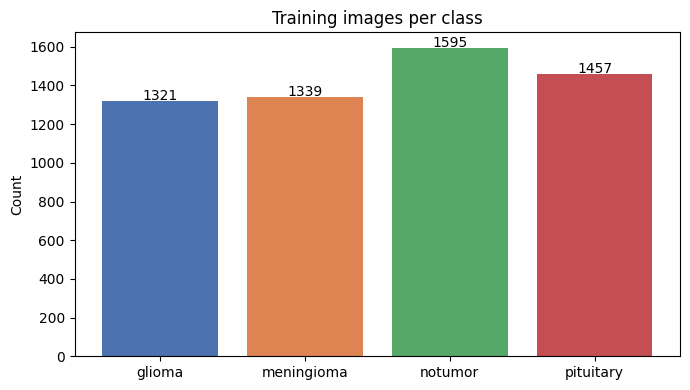

In [5]:
image_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in CLASS_NAMES}

plt.figure(figsize=(7, 4))
bars = plt.bar(image_counts.keys(), image_counts.values(),
                color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
for bar, count in zip(bars, image_counts.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count), ha='center')
plt.title("Training images per class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()

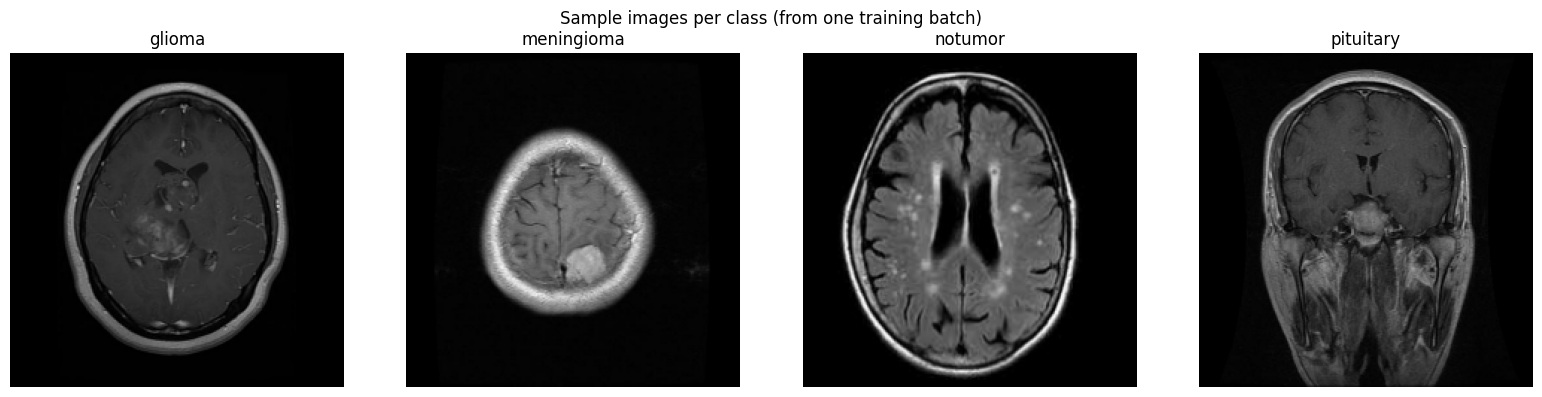

In [6]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
images, labels = next(iter(raw_train_ds))
for idx, cls in enumerate(CLASS_NAMES):
    class_idx = np.argmax(labels.numpy(), axis=1)
    match = np.where(class_idx == idx)[0]
    ax = axes[idx]
    if len(match) > 0:
        ax.imshow(images[match[0]].numpy().astype("uint8"))
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample images per class (from one training batch)")
plt.tight_layout()
plt.show()

## Step 6: CBAM layers

In [7]:
@tf.keras.utils.register_keras_serializable(package="cbam")
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.channels = channels
        self.global_avg_pool = GlobalAveragePooling2D()
        self.global_max_pool = GlobalMaxPooling2D()
        # Shared MLP (same weights applied to both pooled descriptors, per the CBAM paper)
        self.dense1 = Dense(max(channels // self.ratio, 1), activation='relu', use_bias=False)
        self.dense2 = Dense(channels, activation='linear', use_bias=False)
        super().build(input_shape)

    def call(self, inputs):
        avg_pool = self.dense2(self.dense1(self.global_avg_pool(inputs)))
        max_pool = self.dense2(self.dense1(self.global_max_pool(inputs)))
        attention = Activation('sigmoid')(Add()([avg_pool, max_pool]))
        attention = Reshape((1, 1, self.channels))(attention)
        return Multiply()([inputs, attention])

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config


@tf.keras.utils.register_keras_serializable(package="cbam")
class SpatialAttention(Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = Conv2D(
            filters=1, kernel_size=self.kernel_size, strides=1, padding='same',
            activation='sigmoid', use_bias=False
        )
        super().build(input_shape)

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = Concatenate(axis=-1)([avg_pool, max_pool])
        attention = self.conv(concat)
        return Multiply()([inputs, attention])

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config


@tf.keras.utils.register_keras_serializable(package="cbam")
class CBAM(Layer):
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.channel_attention = ChannelAttention(ratio=ratio)
        self.spatial_attention = SpatialAttention(kernel_size=kernel_size)

    def build(self, input_shape):
        self.channel_attention.build(input_shape)
        self.spatial_attention.build(input_shape)
        super().build(input_shape)

    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio, "kernel_size": self.kernel_size})
        return config

## Step 7: Model — DenseNet121 with CBAM at two feature depths

**Design note on "CBAM in 2 layers":** a single CBAM at the very end of DenseNet121 only refines one 7×7, high-level feature map. Here CBAM is applied at **two depths**:

- After `pool4_pool` (14×14×512) — mid-level features, more sensitive to smaller/localized structures.
- After the backbone's final output (7×7×1024) — high-level, whole-image semantic features.


In [8]:
def build_model(num_classes, img_size=IMG_SIZE, cbam_ratio=CBAM_RATIO,
                 cbam_kernel=CBAM_KERNEL, dropout_rate=DROPOUT_RATE):
    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3),
    )
    base_model.trainable = False  # frozen for Phase 1

    # --- Attention point 1: mid-level features ---
    mid_features = base_model.get_layer('pool4_pool').output            # (14, 14, 512)
    mid_refined = CBAM(ratio=cbam_ratio, kernel_size=cbam_kernel, name='cbam_mid')(mid_features)
    mid_pooled = GlobalAveragePooling2D(name='gap_mid')(mid_refined)

    # --- Attention point 2: high-level features ---
    high_features = base_model.output                                    # (7, 7, 1024)
    high_refined = CBAM(ratio=cbam_ratio, kernel_size=cbam_kernel, name='cbam_high')(high_features)
    high_pooled = GlobalAveragePooling2D(name='gap_high')(high_refined)

    # --- Multi-scale fusion + classification head ---
    fused = Concatenate(name='multi_scale_fusion')([mid_pooled, high_pooled])
    x = Dense(256, activation='relu', name='fc1')(fused)
    x = Dropout(dropout_rate, name='dropout')(x)
    output = Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=base_model.input, outputs=output, name='DenseNet121_DualCBAM')
    return model, base_model


model, base_model = build_model(NUM_CLASSES)
model.summary()

Model: "DenseNet121_DualCBAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,759,880 (29.60 MB)

 Trainable params: 722,376 (2.76 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Step 8: Class weights

Computed from the training folder so under-represented classes aren't drowned out during training.

In [9]:
train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in CLASS_NAMES]

class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=np.concatenate([[i] * c for i, c in enumerate(train_counts)])
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights:", dict(zip(CLASS_NAMES, class_weight_values)))

Class weights: {'glioma': np.float64(1.080999242997729), 'meningioma': np.float64(1.0664675130694548), 'notumor': np.float64(0.8952978056426333), 'pituitary': np.float64(0.9800960878517502)}


## Step 9: Callbacks helper

In [10]:
def get_callbacks(checkpoint_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(os.path.join(MODEL_DIR, checkpoint_name), monitor='val_accuracy',
                         save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
    ]

## Step 10: Phase 1 — train the head, backbone frozen

In [11]:
model.compile(
    optimizer=Adam(learning_rate=PHASE1_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'],
)

print("Phase 1: training CBAM + classification head, DenseNet121 backbone frozen")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('phase1_best.keras'),
    shuffle=False,   # shuffling is already handled in the tf.data pipeline (Step 4)
    verbose=1,
)

Phase 1: training CBAM + classification head, DenseNet121 backbone frozen
Epoch 1/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.6837 - loss: 0.9097
Epoch 1: val_accuracy improved from None to 0.89019, saving model to D:\Brain_tumor_project\Notebook\models\phase1_best.keras

Epoch 1: finished saving model to D:\Brain_tumor_project\Notebook\models\phase1_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.7959 - loss: 0.7488 - val_accuracy: 0.8902 - val_loss: 0.5937 - learning_rate: 0.0010
Epoch 2/25
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.8850 - loss: 0.6093
Epoch 2: val_accuracy improved from 0.89019 to 0.91589, saving model to D:\Brain_tumor_project\Notebook\models\phase1_best.keras

Epoch 2: finished saving model to D:\Brain_tumor_project\Notebook\models\phase1_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.8896 - loss: 0.5957 - val_accuracy: 0.9159 - val_loss: 0.5424 - learning_rate: 0.0010
Epoch 3/25
152/152 ━━━━━━━━

## Step 11: Phase 2 — fine-tune the backbone

Unfreeze everything from `UNFREEZE_FROM_BLOCK` onward (`"conv5_block1"` by default — the last DenseNet block), keep BatchNorm layers frozen so their running statistics — tuned on millions of ImageNet images — aren't disrupted by a few thousand MRI scans, and drop the learning rate by two orders of magnitude.

In [12]:
base_model.trainable = True

unfreeze = False
for layer in base_model.layers:
    if layer.name.startswith(UNFREEZE_FROM_BLOCK):
        unfreeze = True
    layer.trainable = unfreeze and not isinstance(layer, tf.keras.layers.BatchNormalization)

trainable_count = sum(l.trainable for l in base_model.layers)
print(f"{trainable_count} / {len(base_model.layers)} backbone layers trainable in Phase 2")

model.compile(
    optimizer=Adam(learning_rate=PHASE2_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'],
)

print("Phase 2: fine-tuning top of the backbone")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('phase2_best.keras'),
    shuffle=False,
    verbose=1,
)

81 / 427 backbone layers trainable in Phase 2
Phase 2: fine-tuning top of the backbone
Epoch 1/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.9985 - loss: 0.3711
Epoch 1: val_accuracy improved from None to 0.95794, saving model to D:\Brain_tumor_project\Notebook\models\phase2_best.keras

Epoch 1: finished saving model to D:\Brain_tumor_project\Notebook\models\phase2_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9994 - loss: 0.3707 - val_accuracy: 0.9579 - val_loss: 0.4439 - learning_rate: 1.0000e-05
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.9998 - loss: 0.3682
Epoch 2: val_accuracy improved from 0.95794 to 0.96145, saving model to D:\Brain_tumor_project\Notebook\models\phase2_best.keras

Epoch 2: finished saving model to D:\Brain_tumor_project\Notebook\models\phase2_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9996 - loss: 0.3684 - val_accuracy: 0.9614 - val_loss: 0.4410 - learning_rate: 1.0000e-05
Epoch 

## Step 12: Training curves

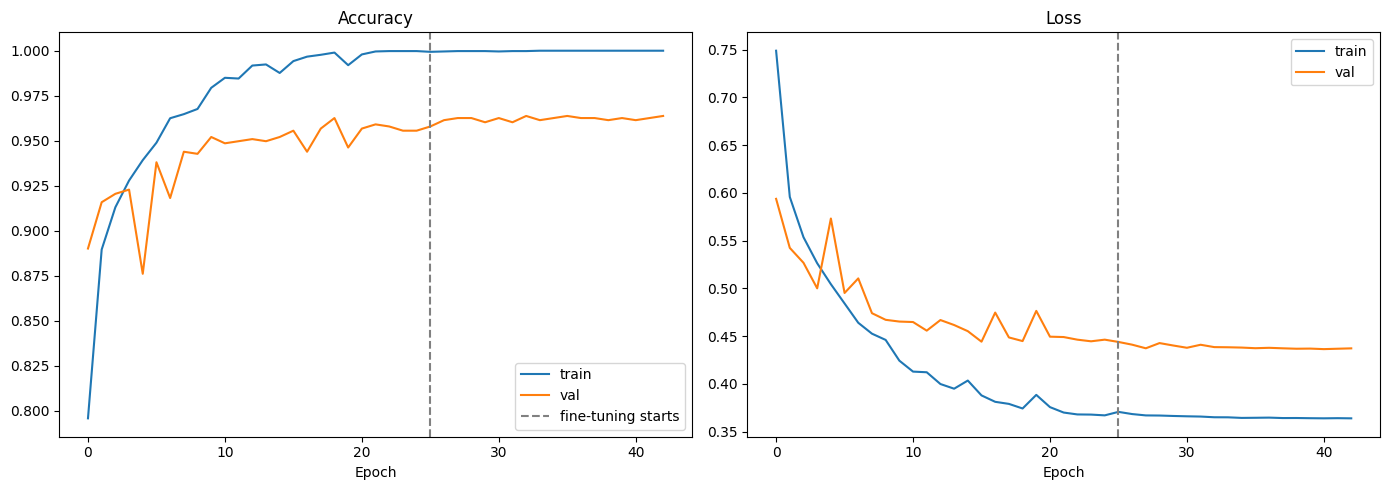

In [13]:
def combine(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc, val_acc = combine(history_phase1, history_phase2, 'accuracy'), combine(history_phase1, history_phase2, 'val_accuracy')
loss, val_loss = combine(history_phase1, history_phase2, 'loss'), combine(history_phase1, history_phase2, 'val_loss')
phase_boundary = len(history_phase1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(acc, label='train'); axes[0].plot(val_acc, label='val')
axes[0].axvline(phase_boundary, color='gray', linestyle='--', label='fine-tuning starts')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(loss, label='train'); axes[1].plot(val_loss, label='val')
axes[1].axvline(phase_boundary, color='gray', linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

## Step 13: Evaluate on the held-out test set

In [14]:
y_pred_prob = model.predict(test_ds)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])
y_pred = np.argmax(y_pred_prob, axis=1)

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print("=" * 50)
print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 958ms/step
Test Accuracy : 0.9603
Test Precision: 0.9610
Test Recall   : 0.9603
Test F1 Score : 0.9604

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.91      0.93       300
  meningioma       0.90      0.94      0.92       306
     notumor       1.00      0.99      1.00       405
   pituitary       0.98      0.99      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



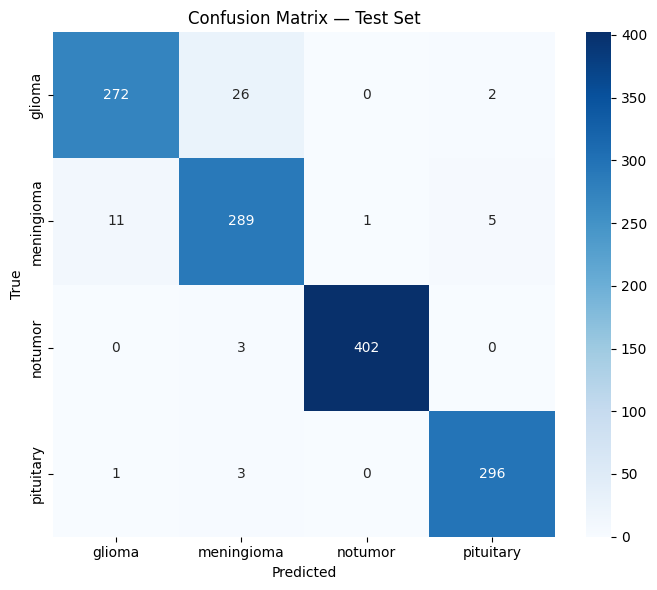

In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

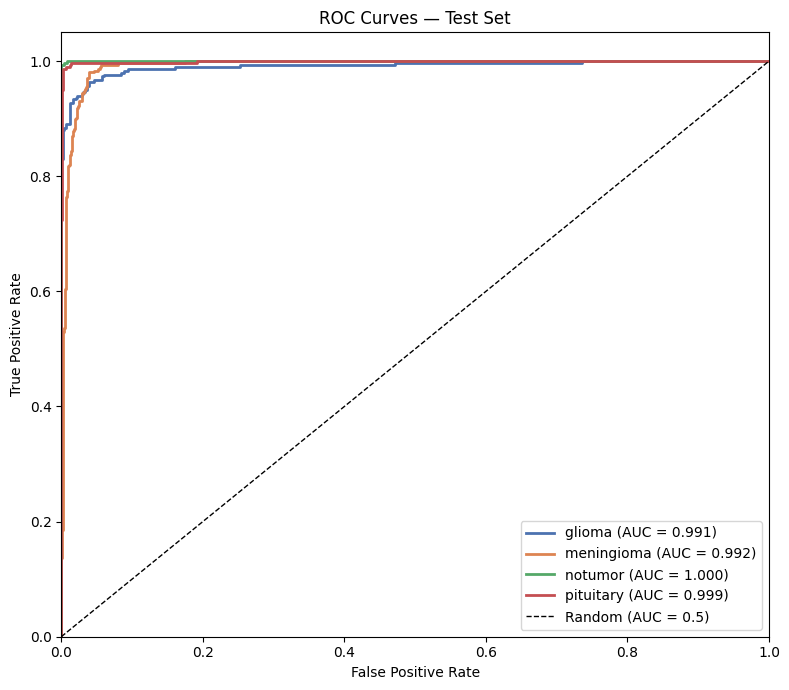

In [16]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(8, 7))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

## Step 14: Grad-CAM — where is the model looking?

Explains predictions using the post-attention feature map from the high-level CBAM block (`cbam_high`), so the heatmap reflects what the attention mechanism actually emphasizes, not the raw backbone features.

In [17]:
grad_model = Model(inputs=model.input, outputs=[model.get_layer('cbam_high').output, model.output])

def get_gradcam_heatmap(img_batch, class_idx=None):
    if class_idx is None:
        preds = model.predict(img_batch, verbose=0)
        class_idx = np.argmax(preds[0])
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_batch)
        class_score = predictions[:, class_idx]
    grads = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output), axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy(), class_idx

def overlay_heatmap(original_img_uint8, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap_resized = cv2.resize(heatmap, (original_img_uint8.shape[1], original_img_uint8.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(original_img_uint8, 1 - alpha, heatmap_colored, alpha, 0)

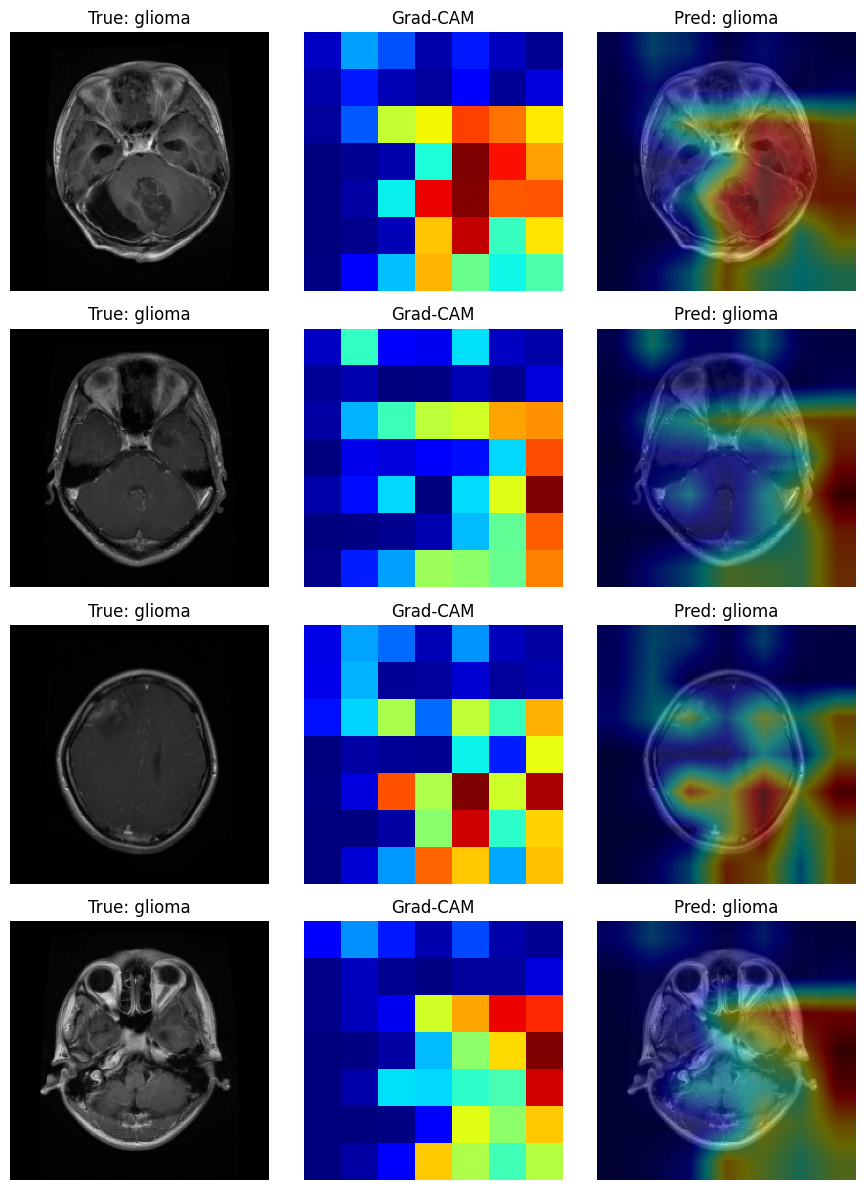

In [18]:
# Visualize Grad-CAM for a handful of test examples in one consolidated figure
raw_batch_images, raw_batch_labels = next(iter(raw_test_ds))
prep_batch_images, _ = next(iter(test_ds))

n_show = min(4, raw_batch_images.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for row in range(n_show):
    original_uint8 = raw_batch_images[row].numpy().astype(np.uint8)
    img_batch = prep_batch_images[row:row + 1]
    true_label = CLASS_NAMES[np.argmax(raw_batch_labels[row].numpy())]

    heatmap, pred_idx = get_gradcam_heatmap(img_batch)
    overlay = overlay_heatmap(original_uint8, heatmap)

    axes[row, 0].imshow(original_uint8); axes[row, 0].set_title(f"True: {true_label}"); axes[row, 0].axis('off')
    axes[row, 1].imshow(heatmap, cmap='jet'); axes[row, 1].set_title('Grad-CAM'); axes[row, 1].axis('off')
    axes[row, 2].imshow(overlay); axes[row, 2].set_title(f"Pred: {CLASS_NAMES[pred_idx]}"); axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gradcam_examples.png'), dpi=200, bbox_inches='tight')
plt.show()

## Step 15: Save the final model

One file, `.keras` format (native, reliable custom-layer serialization) 

In [19]:
final_path = os.path.join(MODEL_DIR, 'brain_tumor_densenet121_dualcbam_final.keras')
model.save(final_path)
print("Saved:", final_path)

Saved: D:\Brain_tumor_project\Notebook\models\brain_tumor_densenet121_dualcbam_final.keras


In [20]:
# Verify it reloads and evaluates identically
reloaded = tf.keras.models.load_model(
    final_path,
    custom_objects={'ChannelAttention': ChannelAttention, 'SpatialAttention': SpatialAttention, 'CBAM': CBAM}
)
reloaded_results = reloaded.evaluate(test_ds, verbose=0)
print(f"Reloaded model — test loss: {reloaded_results[0]:.4f}, test accuracy: {reloaded_results[1]:.4f}")

Reloaded model — test loss: 0.4272, test accuracy: 0.9603


## Step 16: Pushing past 90%



In [21]:
# ============================================================
# Cell: Grad-CAM setup and helper functions
# ============================================================

# Build a model that returns both the post-CBAM high-level feature map
# AND the final predictions. Grad-CAM will use gradients w.r.t. the
# feature map to localize what the model focused on.
grad_model = Model(
    inputs=model.input,
    outputs=[model.get_layer('cbam_high').output, model.output]
)


def get_gradcam_heatmap(img_batch, class_idx=None):
    """
    Compute a Grad-CAM heatmap for a single image batch (batch size 1).

    Args:
        img_batch : np.ndarray of shape (1, H, W, 3), preprocessed.
        class_idx : int or None. If None, uses the argmax of the prediction.

    Returns:
        heatmap   : np.ndarray of shape (h, w) with values in [0, 1]
        class_idx : int, the class used for the gradient computation
    """
    if class_idx is None:
        preds = model.predict(img_batch, verbose=0)
        class_idx = int(np.argmax(preds[0]))

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_batch, training=False)
        class_score = predictions[:, class_idx]

    # Gradient of the target class score w.r.t. the conv feature map
    grads = tape.gradient(class_score, conv_output)

    if grads is None:
        raise RuntimeError(
            "Gradients are None — make sure cbam_high is part of the "
            "model graph and is not disconnected."
        )

    # Global-average-pool the gradients over spatial dims -> (channels,)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature map channels by the pooled gradients
    conv_output = conv_output[0]                      # (h, w, C)
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)  # (h, w)

    # ReLU + normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy(), class_idx


def overlay_heatmap(original_img_uint8, heatmap, alpha=0.4,
                    colormap=cv2.COLORMAP_JET):
    """
    Overlay a Grad-CAM heatmap on an RGB image.

    Args:
        original_img_uint8 : np.ndarray (H, W, 3), dtype uint8, RGB order.
        heatmap            : np.ndarray (h, w), values in [0, 1].
        alpha              : float, blending factor for the heatmap.
        colormap           : cv2 colormap constant.

    Returns:
        overlaid RGB image as np.ndarray (H, W, 3), dtype uint8.
    """
    # Resize heatmap to match the original image
    heatmap_resized = cv2.resize(
        heatmap,
        (original_img_uint8.shape[1], original_img_uint8.shape[0])
    )

    # Scale to [0, 255] and apply colormap
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, colormap)

    # OpenCV returns BGR — convert to RGB to match the original image
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Blend
    overlaid = cv2.addWeighted(
        original_img_uint8, 1 - alpha,
        heatmap_colored,   alpha,
        0
    )
    return overlaid

In [22]:
def generate_gradcam(image_path, model, last_conv_layer="top_conv"):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Preprocess for EfficientNet
    input_arr = preprocess_input(np.expand_dims(img_resized, axis=0))

    # Create heatmap
    heatmap = make_gradcam_heatmap(input_arr, model, last_conv_layer)

    # Resize heatmap to original image size
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))

    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img_rgb, 0.65, heatmap_color, 0.35, 0)

    # Show results
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img_rgb)
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.show()


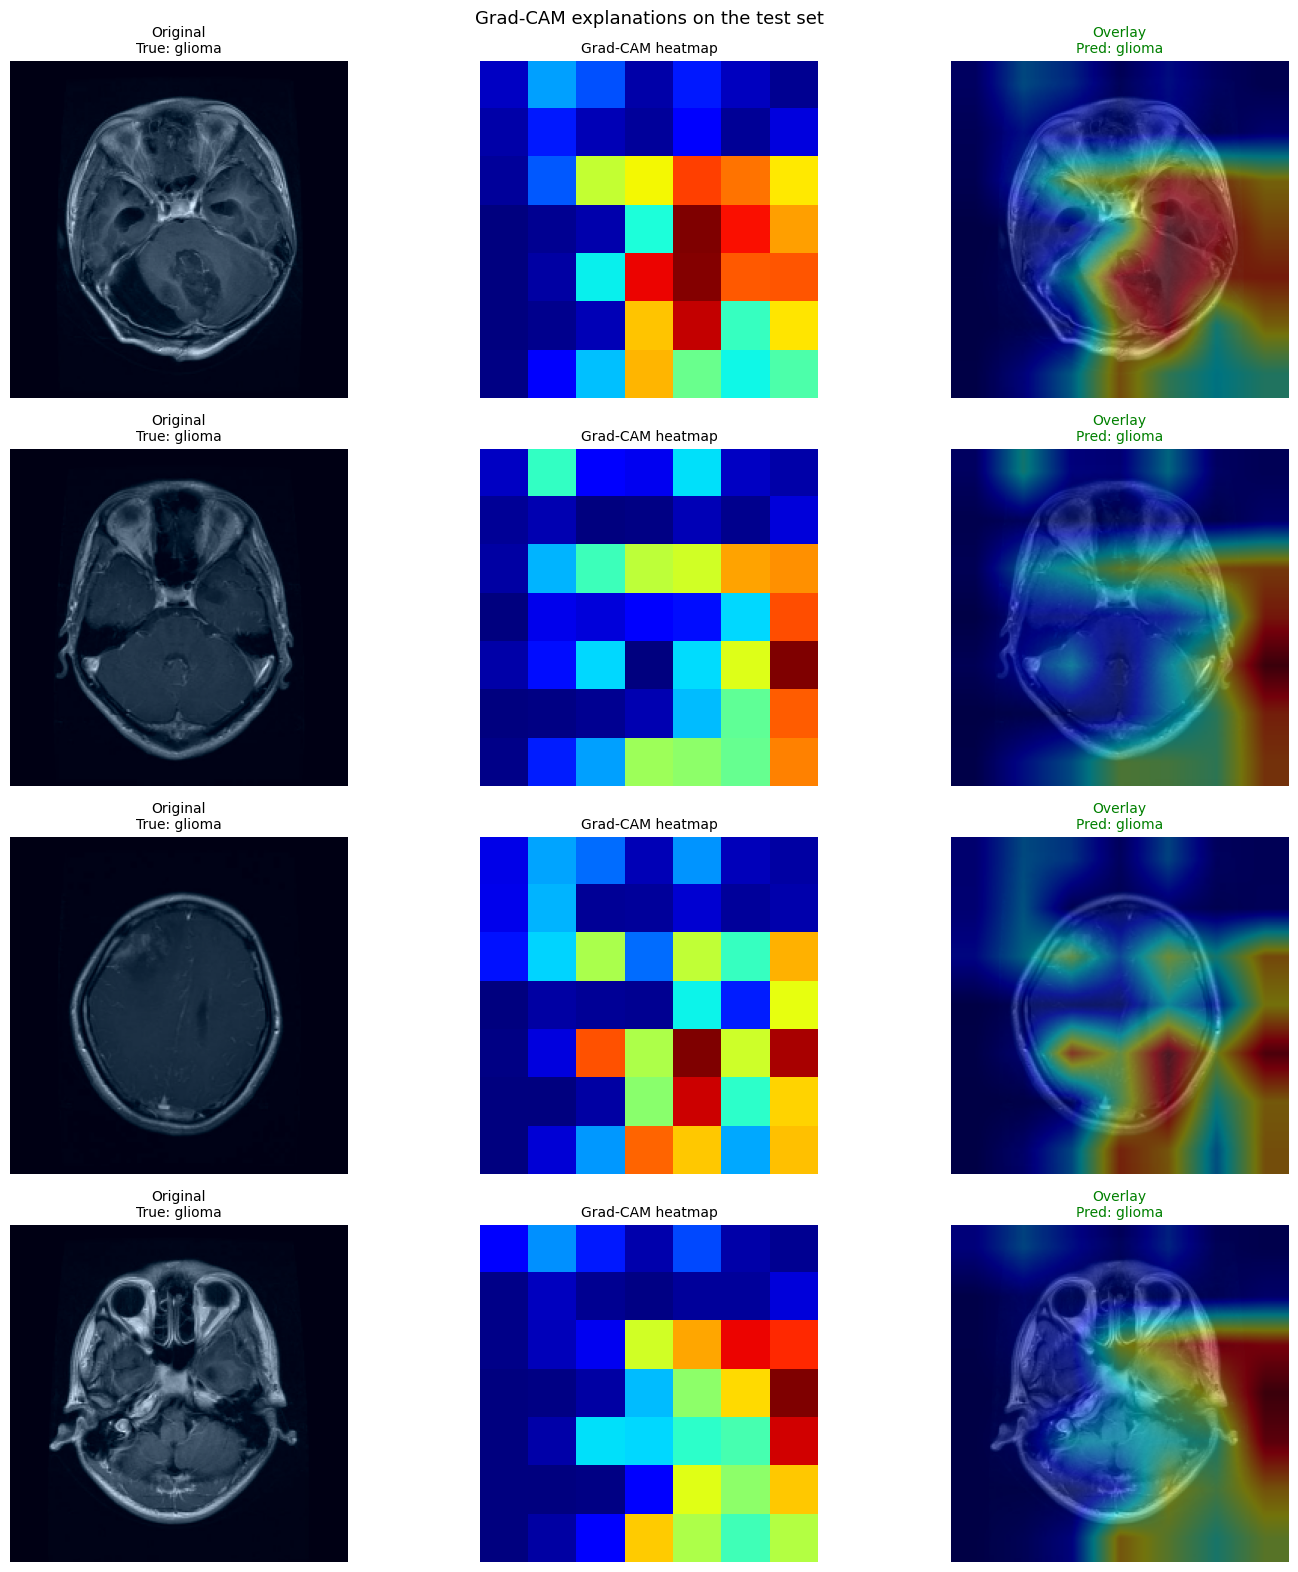

In [23]:
# ============================================================
# Cell: Grad-CAM visualization on sample test images
# ============================================================

def unnormalize_for_display(img_tensor):
    """
    Our test_ds was produced by preprocess_input() (DenseNet preprocessing),
    which does NOT map pixels to a simple [0, 1] range — it uses a per-channel
    mean/std normalization. For display, we re-do the standard ImageNet
    un-normalization to recover an approximate [0, 255] RGB image.
    """
    # Reverse DenseNet preprocessing:
    #   preprocess_input(x) = (x - mean) / std   (per-channel, on [0,255] scale)
    # so to invert: x = y * std + mean
    mean = np.array([103.939, 116.779, 123.68], dtype=np.float32)
    std  = np.array([58.395, 57.12, 57.375], dtype=np.float32)  # note: TF DenseNet uses these
    img = img_tensor.numpy().copy()
    img = img * std + mean
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img


# Take one batch from the test set
for images, labels in test_ds.take(1):
    num_to_show = min(4, images.shape[0])

    plt.figure(figsize=(15, 4 * num_to_show))

    for i in range(num_to_show):
        img_batch = images[i:i + 1]                     # (1, H, W, 3)
        img_uint8 = unnormalize_for_display(images[i])  # (H, W, 3), RGB

        true_idx  = int(np.argmax(labels[i].numpy()))
        true_name = CLASS_NAMES[true_idx]

        heatmap, pred_idx = get_gradcam_heatmap(img_batch, class_idx=None)
        pred_name = CLASS_NAMES[pred_idx]

        overlaid = overlay_heatmap(img_uint8, heatmap, alpha=0.45)

        # --- Original ---
        ax1 = plt.subplot(num_to_show, 3, 3 * i + 1)
        ax1.imshow(img_uint8)
        ax1.set_title(f"Original\nTrue: {true_name}", fontsize=10)
        ax1.axis("off")

        # --- Heatmap ---
        ax2 = plt.subplot(num_to_show, 3, 3 * i + 2)
        ax2.imshow(heatmap, cmap="jet")
        ax2.set_title("Grad-CAM heatmap", fontsize=10)
        ax2.axis("off")

        # --- Overlay ---
        ax3 = plt.subplot(num_to_show, 3, 3 * i + 3)
        ax3.imshow(overlaid)
        color = "green" if pred_idx == true_idx else "red"
        ax3.set_title(f"Overlay\nPred: {pred_name}", fontsize=10, color=color)
        ax3.axis("off")

    plt.suptitle("Grad-CAM explanations on the test set", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_examples.png"),
                dpi=200, bbox_inches="tight")
    plt.show()
    break

Collected 160 test samples to search.


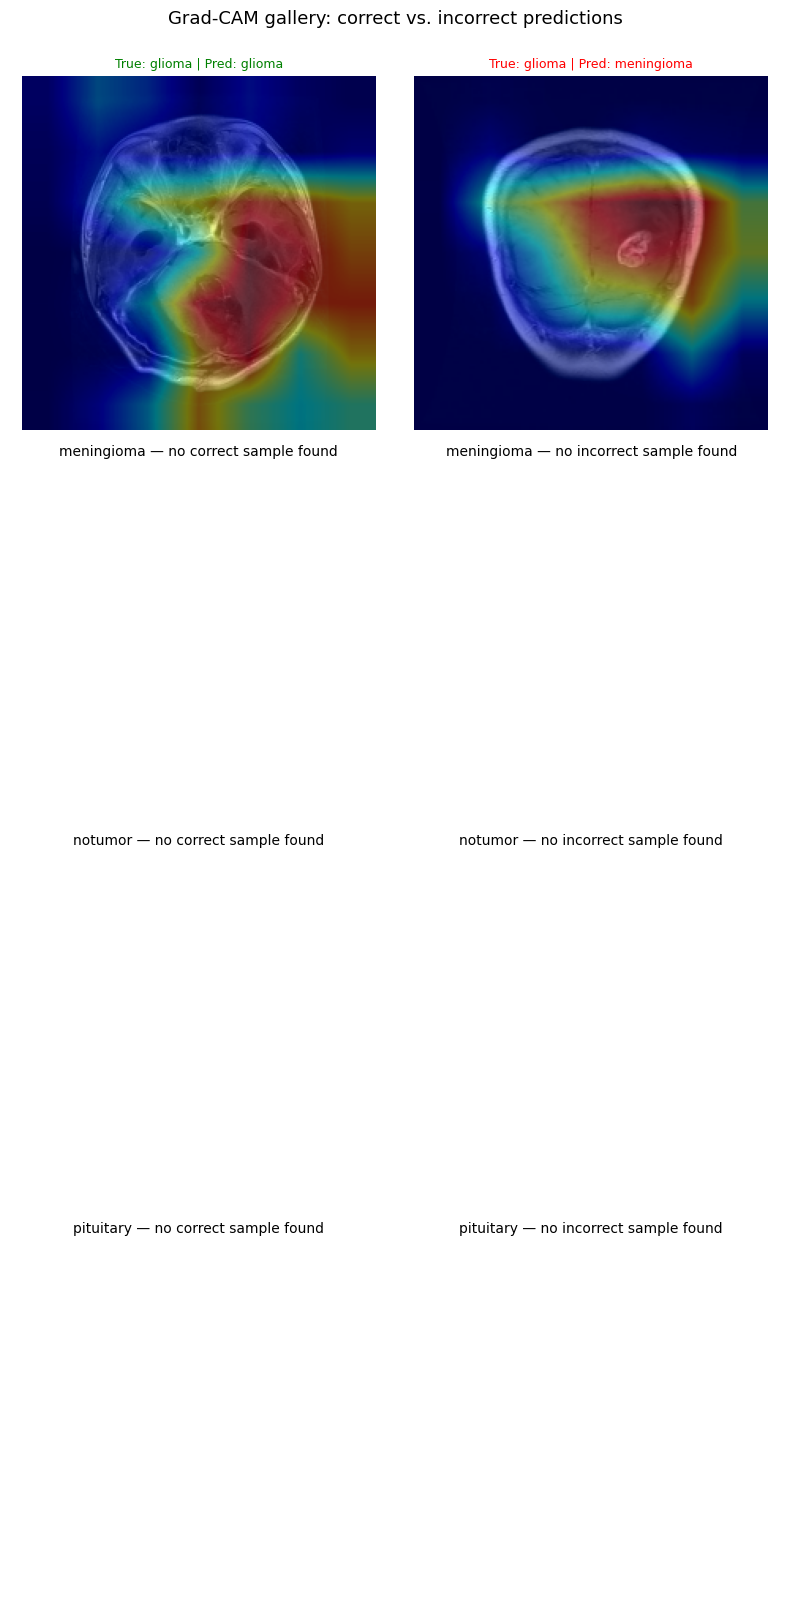

In [24]:
# ============================================================
# Cell: Grad-CAM gallery — one correct + one incorrect per class
# ============================================================

# Collect up to N batches to search through
search_batches = 5
samples = []
for images, labels in test_ds.take(search_batches):
    for i in range(images.shape[0]):
        samples.append((images[i], int(np.argmax(labels[i].numpy()))))

print(f"Collected {len(samples)} test samples to search.")

# Find best "correct" and "incorrect" example for each class
picks = {cls: {"correct": None, "incorrect": None} for cls in CLASS_NAMES}

for img, true_idx in samples:
    img_batch = img.numpy()[None, ...]
    preds = model.predict(img_batch, verbose=0)
    pred_idx = int(np.argmax(preds[0]))

    true_name = CLASS_NAMES[true_idx]
    if pred_idx == true_idx and picks[true_name]["correct"] is None:
        picks[true_name]["correct"] = (img, true_idx, pred_idx)
    elif pred_idx != true_idx and picks[true_name]["incorrect"] is None:
        picks[true_name]["incorrect"] = (img, true_idx, pred_idx)

    # Early exit
    if all(picks[c]["correct"] and picks[c]["incorrect"] for c in CLASS_NAMES):
        break

# Plot a grid: rows = classes, cols = [correct, incorrect]
fig, axes = plt.subplots(len(CLASS_NAMES), 2,
                         figsize=(8, 4 * len(CLASS_NAMES)))

for row, cls in enumerate(CLASS_NAMES):
    for col, kind in enumerate(["correct", "incorrect"]):
        ax = axes[row, col]
        pick = picks[cls][kind]

        if pick is None:
            ax.set_title(f"{cls} — no {kind} sample found", fontsize=10)
            ax.axis("off")
            continue

        img, true_idx, pred_idx = pick
        img_uint8 = unnormalize_for_display(img)
        heatmap, _ = get_gradcam_heatmap(img.numpy()[None, ...],
                                         class_idx=pred_idx)
        overlaid = overlay_heatmap(img_uint8, heatmap, alpha=0.45)

        ax.imshow(overlaid)
        ax.set_title(
            f"True: {CLASS_NAMES[true_idx]} | Pred: {CLASS_NAMES[pred_idx]}",
            fontsize=9,
            color="green" if kind == "correct" else "red",
        )
        ax.axis("off")

plt.suptitle("Grad-CAM gallery: correct vs. incorrect predictions",
             fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_gallery.png"),
            dpi=200, bbox_inches="tight")
plt.show()